# Nearest neighbour analysis

The idea of neighbourhood is one of the fundamental concepts in geographic data analysis and modelling. Being able to understand how close geographic objects are to each other, or which features are neighboring a specific location is fundamental to various spatial analysis techniques, such as spatial interpolation (which we cover in Chapter 10) or understanding whether there is spatial autocorrelation (i.e. clustering) in the data (see Chapters [6](https://geographicdata.science/book/notebooks/06_spatial_autocorrelation.html) and [7](https://geographicdata.science/book/notebooks/07_local_autocorrelation.html) in {cite}`Rey_et_al_2023`). Many of these techniques rely on the idea that proximity in geographic space typically indicates also similarity in attribute space. For example, it is quite typical that a neighborhood with high population density is next to another neighborhood that also has high concentration of residents (i.e. population density tends to cluster). One of the most famous notions related to this is the *First law of geography* which states that "everything is related to everything, but near things are more related than distant things" ({cite}`Tobler1970`). Thus, being able to understand how close neighboring geographic features are, or which objects are the closest ones to specific location is an important task in GIS. 

Figure 6.45 illustrates two common ways to find nearest neighbors to specific locations. In these examples, we have two Point datasets visualized with blue circles and red rectangles that are used for doing the nearest neighbor analysis. In the first example (top row), the idea is to find the closest geometry (rectangles) for all the points in the area. Here, the nearest neighbor is determined based on distance between the points and rectangles, and the nearest neighbors are visualized with a line from every point to the closest rectangle (on the right). The bottom row shows an example in which we aim to find the closest point for each rectangle, but in this case we also apply a maximum search distance that limits the search area. Only those points that are within the search area are considered when finding the nearest neighbor, while the points outside of this area are simply ignored. As a result, the point closest to a given rectangle is visualized with a connected line (on the right). In these examples, the geographic objects are simple point like features, but similar approach can be used with any geographic features, for example by finding closest LineString or Polygon geometry to a given Point, or by finding the closest Polygon to another Polygon. In these cases, the calculations are a bit more complicated, but the basic idea is the same. 

![_**Figure 6.46**. The basic idea of finding a nearest neighbour based on geographic distance._](../img/nearest-neighbour.png)

_**Figure 6.46**. The basic idea of finding a nearest neighbour based on geographic distance._

Quite often with very large datasets, we might want to limit the search area up to a specific maximum distance. This can be due to practical reasons as it can significantly speed up the computation time, or because we have specific reasoning that makes it sensible to limit the search area. For example, if we would aim to understand how easily accessible public transportation is to citizens living in a city, it would make sense to limit the search area e.g. up to 2 km from the homes of people, because people are not willing to walk for very long distances to reach a bus stop. It's important to notice that the distances in the calculations are commonly based on the Euclidean distance, i.e. we calculate the distances based on coordinates on a Cartesian plain, meaning that the distances do not consider changes in height (i.e. third dimension is omitted). It is of course possible also to consider 3D distances, but the most typical Python tools ignore the height information. 

## Nearest neighbour analysis in Python

In Python, there are various libraries that can be used to find nearest neighbors for given set of geometries, including `geopandas`, `shapely`, `scipy`, `scikit-learn`, and `pysal` among others. Here, we first introduce how `geopandas` can be used to find the nearest neighbors for all Point geometries in a given `GeoDataFrame` based on `Point`objects from another `GeoDataFrame`. Then we show how to find nearest neighbor between two Polygon datasets, and finally we show how to use `scipy` library to find K-Nearest Neighbors (KNN) with Point data.

In the following, we go through a very practical example that relates to our daily commute: Where is the closest public transport stop from my place of residence? Hence, our aim is to search for each building point in the Helsinki Region the closest public transport stop. In `geopandas`, we can find nearest neighbors for all geometries in a given `GeoDataFrame` using the `.sjoin_nearest()` method. To test it out, let's start by reading two datasets representing buildings and stops and visualize them to understand a bit better what we have:

In [8]:
import geopandas as gpd
import matplotlib.pyplot as plt

stops = gpd.read_file("data/Helsinki/pt_stops_helsinki.gpkg")
building_points = gpd.read_file("data/Helsinki/building_points_helsinki.zip")

print("Number of stops:", len(stops))
stops.head(2)

Number of stops: 8377


,stop_name,stop_lat,stop_lon,stop_id,geometry
0,Ritarihuone,60.16946,24.95667,1010102,POINT (24.95667 60.16946)
1,Kirkkokatu,60.17127,24.95657,1010103,POINT (24.95657 60.17127)


In [9]:
print("Number of buildings:", len(building_points))
building_points.head(2)

Number of buildings: 158731


,name,geometry
0,None,POINT (24.85584 60.20727)
1,Uimastadion,POINT (24.93045 60.18882)


As we can see, both `GeoDataFrames` contain `Point` geometries. There seems to be approximately 8400 stops and almost 159 thousand buildings. Hence, we have already a fair amount of data and calculations to do, to find the nearest neighbor for each building. Let's still visualize these data side-by-side:

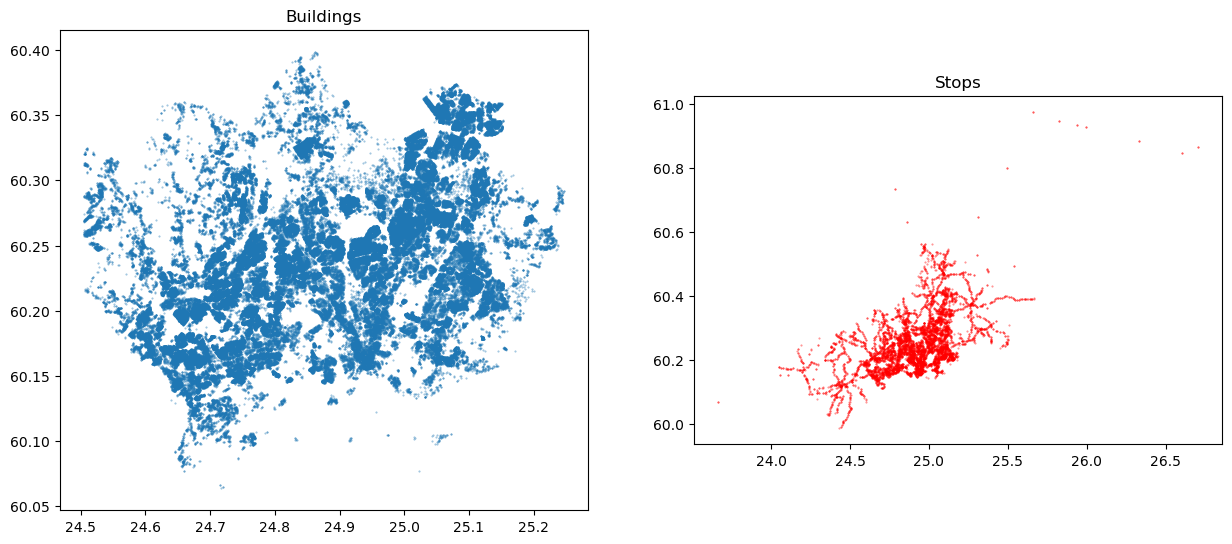

In [10]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(15, 10))

# Plot buildings
building_points.plot(ax=ax1, markersize=0.2, alpha=0.5)
ax1.set_title("Buildings")

# Plot stops
stops.plot(ax=ax2, markersize=0.2, alpha=0.5, color="red")
ax2.set_title("Stops");

_**Figure 6.47**. Maps representing the buildings and public transport stops which we use to find the closest stop for each building._

As mentioned earlier, finding the nearest geometries between two `GeoDataFrames` (here building and stop points) can be done easily using the `.sjoin_nearest()` method in `geopandas`. As the name implies, this method is actually designed to merge data between `GeoDataFrames` in a similar manner as with regular `.sjoin()` method. However, in this case the method is actually searching for the closest geometries instead of relying on spatial predicates, such as *within*. The `sjoin_nearest()` can be used for different geometry types, so the input geometries do not necessarily need to be Point objects as in our example. Under the hood, the method uses a *{term}`spatial index`* called `STRTree` ({cite}`leutenegger_1997`) which is an efficient implementation of the *{term}`R-tree`* dynamic index structure for spatial searching ({cite}`guttman_1984`). The STRTree is implemented in the `shapely` library (used by `geopandas`) and the technique makes the nearest neighbor queries very efficient. You can read more about spatial indices in Appendices section of the book. For the method to work properly, it is recommended to ensure that the both `GeoDataFrames` are having the same coordinate reference system (CRS), and preferably having a projected (metric) CRS because that ensures that the reported distances are meaningful (in meters) and correct. Hence, let's start by reprojecting our latitude and longitude values into a metric system using the national EUREF-FIN coordinate reference system (EPSG code 3067) for Finland:

In [11]:
stops = stops.to_crs(epsg=3067)
building_points = building_points.to_crs(epsg=3067)

stops.head(2)

,stop_name,stop_lat,stop_lon,stop_id,geometry
0,Ritarihuone,60.16946,24.95667,1010102,POINT (386623.301 6672037.884)
1,Kirkkokatu,60.17127,24.95657,1010103,POINT (386623.991 6672239.572)


Now the `GeoDataFrames` are surely in the same coordinate system and we can see that the coordinates in the `geometry` column have changed representing meters. Next, we will use the `buildings.sjoin_nearest()` to find the closest stop for each building. Because we are interested to find the closest stop geometry for each building, the `buildings` `GeoDataFrame` is on the left hand side of the command. As inputs, we pass the `stops` `GeoDataFrame` as well as give a name for a column which is used to store information about the distance between a given building and the closest stop (this is optional):

In [21]:
%time
closest = building_points.sjoin_nearest(stops, distance_col="distance")
closest

CPU times: user 3 μs, sys: 5 μs, total: 8 μs
Wall time: 19.1 μs


,name,geometry,index_right,stop_name,stop_lat,stop_lon,stop_id,distance
0,None,POINT (381166.6 6676424.438),1131,Muusantori,60.20749,24.857450,1304138,92.679893
1,Uimastadion,POINT (385236.565 6674238.472),467,Auroran sairaala,60.19145,24.925540,1171122,400.243370
2,None,POINT (386317.478 6672100.648),61,Senaatintori,60.16901,24.950460,1020450,109.819633
3,Hartwall Arena,POINT (385225.109 6676120.56),532,Veturitie,60.20661,24.929680,1174112,104.632434
4,Talli,POINT (385079.733 6676989.745),496,Posti 1,60.21345,24.917550,1172143,472.248282
...,...,...,...,...,...,...,...,...
158726,None,POINT (373896.051 6677472.204),4621,Samis,60.21369,24.720970,3170209,195.675552
158727,None,POINT (372425.65 6676945.528),4654,Yrjö Liipolan tie,60.20922,24.695470,3170244,137.137640
158728,None,POINT (374696.625 6677972.738),4655,Kandidaatintie,60.21818,24.736987,3170245,135.341745
158729,Granhultsskolan,POINT (373287.582 6677731.639),4624,Uimahalli,60.21638,24.711260,3170212,99.408108


As a result, we now have found the closest stop for each building including the attributes of the closest stops that were merged into the results. The last column in the table shows the distance in meters between a given building and the closest stop. The distance is only returned upon request as we did by specifying `distance_col="distance"`. The column `index_right` provides information about the index number of the closest stop in the `stops` `GeoDataFrame`. If you look carefully, you can see that the number of rows in our result has actually increased slightly from the original (158731 vs 159818). This happens because for some geometries in the `buildings` `GeoDataFrame`, the distance between the building and two (or more) stops have been exactly the same (i.e. they are equidistant). In such cases, the `sjoin_nearest()` will store both records into the results by duplicating the building information and attaching information from the stops into separate rows accordingly. In some cases, this can cause trouble for further analysis, so it is good to be careful and investigate whether any duplicate buildings have appeared into the results. If this is the case, and if the duplicates cause issues in your analysis, you might need to pick one of them for further analysis based on some criteria. A simple way is to pick the first (or last) duplicate if you do not have any specific justification for making the selection.

The `%time` command at the beginning of the cell provides us some details about the time it took to find the nearest neighbors and merge the data between the two data sets. As we can see, the computations are very efficient taking only a matter of some microseconds for almost 159 thousand observations. We can make this even faster by specifying a `max_distance` parameter that specifies the maximum search distance. Here, we specify the maximum distance as 100 meters from each building:

In [13]:
%time
closest_limited = building_points.sjoin_nearest(
    stops, max_distance=100, distance_col="distance"
)
closest_limited

CPU times: user 5 μs, sys: 2 μs, total: 7 μs
Wall time: 11 μs


,name,geometry,index_right,stop_name,stop_lat,stop_lon,stop_id,distance
0,None,POINT (381166.6 6676424.438),1131,Muusantori,60.207490,24.857450,1304138,92.679893
10,None,POINT (384645.078 6669763.917),592,Hernesaaren laituri,60.148287,24.923281,1204101,57.786201
12,None,POINT (384782.782 6669707.017),595,Hernesaaren laituri,60.148680,24.924240,1204108,79.844881
13,None,POINT (384714.47 6669710.887),592,Hernesaaren laituri,60.148287,24.923281,1204101,32.640335
16,None,POINT (385040.806 6670639.517),596,Hernesaarenkatu,60.156110,24.930370,1204109,87.888087
...,...,...,...,...,...,...,...,...
158718,None,POINT (374219.973 6677006.1),4651,Kauniaisten asema,60.210830,24.729330,3170240,69.803673
158719,None,POINT (374231.494 6676967.402),4642,Kauniaistentie,60.209810,24.731510,3170230,63.384115
158720,None,POINT (374602.815 6677396.18),4673,Raamattuopisto,60.213524,24.736685,3170265,56.594370
158729,Granhultsskolan,POINT (373287.582 6677731.639),4624,Uimahalli,60.216380,24.711260,3170212,99.408108


As we can see, there was a slight improvement in the execution time compared to the previous call without specifying the `max_distance` parameter. The difference can be more significant if you have larger datasets or more complicated geometries (e.g. Polygons). One important aspect to notice from these results is that the number of rows has decreased significantly: from 160 to 40 thousand buildings. This happens because our search distance was very low (100 meters), and as a consequence, there were many buildings that did not have any stops within 100 meter radius from them. Because the default join type in `sjoin_nearest` is `inner` join, all the records that did not have a stop within 100 meters were dropped. If you would like to keep all the records in the results, to e.g. investigate which buildings do not have any stops within the search radius, you can add parameter `how="left"`, which will retain all buildings from the original `GeoDataFrame`.

In some cases, you might actually want to connect the nearest neighbors to each other with a straight line. For doing this, we need to merge also the Point geometries from the other layer into our results, which can then be used to create a LineString connecting the points to each other. This can be useful for many purposes, but in our case, we want to do this to be able to validate whether our results are correct. For merging the closest stop geometries into our results, we can take advantage of the `index_right` column in our table and conduct a normal table join using the `.merge()` method. Below, we create a table join between the tables using the `.merge()` and use the `"index_right"` column in the `closest` `GeoDataFrame` as a key on the left table while the index of the `stops` is used as the key on the right table. Notice that we only keep the `geometry` columns from the `stops` `GeoDataFrame` because all the other attributes already exist in our results: 

In [22]:
closest = closest.merge(
    stops[[stops.active_geometry_name]], left_on="index_right", right_index=True
)
closest.head()

,name,geometry_x,index_right,stop_name,stop_lat,stop_lon,stop_id,distance,geometry_y
0,None,POINT (381166.6 6676424.438),1131,Muusantori,60.20749,24.85745,1304138,92.679893,POINT (381256.66 6676446.317)
1,Uimastadion,POINT (385236.565 6674238.472),467,Auroran sairaala,60.19145,24.92554,1171122,400.243370,POINT (384973.331 6674539.973)
2,None,POINT (386317.478 6672100.648),61,Senaatintori,60.16901,24.95046,1020450,109.819633,POINT (386277.25 6671998.462)
3,Hartwall Arena,POINT (385225.109 6676120.56),532,Veturitie,60.20661,24.92968,1174112,104.632434,POINT (385255.784 6676220.595)
4,Talli,POINT (385079.733 6676989.745),496,Posti 1,60.21345,24.91755,1172143,472.248282,POINT (384607.679 6677003.267)


As a result, we now brought a new column into our results, namely the `geometry_y`. Because there was a column called `geometry` in both `GeoDataFrames`, `geopandas` automatically renamed the columns into `geometry_x` and `geometry_y` respectively. 

Now we have all the data that we need to create a connecting `LineString` between the buildings and the closest stops. We can do this by using the `linestrings()` function of the `shapely` library which is a fast (vectorized) way to create a number of `LineString` objects based on point coordinates (the function only accepts numbers as input, i.e. not `Point` objects). To extract the point coordinates from the `Point` objects stored in the `geometry_x` and `geometry_y` columns, we use the `.get_coordinates()` method of `geopandas` that returns the `x` and `y` coordinates as `Series` objects/columns. Then we convert these into `numpy` arrays using the `to_numpy()` method which we pass to the `linestrings()` function. Finally, we store the resulting `LineStrings` into a column `geometry` which we set as the active geometry of the `GeoDataFrame`:    

In [40]:
from shapely import linestrings

closest["geometry"] = linestrings(
    closest.geometry_x.get_coordinates().to_numpy(),
    closest.geometry_y.get_coordinates().to_numpy(),
)

closest = closest.set_geometry("geometry")
closest.head()

,name,geometry_x,index_right,stop_name,stop_lat,stop_lon,stop_id,distance,geometry_y,geometry
0,None,POINT (381166.6 6676424.438),1131,Muusantori,60.20749,24.85745,1304138,92.679893,POINT (381256.66 6676446.317),"LINESTRING (381166.6 381256.66, 6676424.438 66..."
1,Uimastadion,POINT (385236.565 6674238.472),467,Auroran sairaala,60.19145,24.92554,1171122,400.243370,POINT (384973.331 6674539.973),"LINESTRING (385236.565 384973.331, 6674238.472..."
2,None,POINT (386317.478 6672100.648),61,Senaatintori,60.16901,24.95046,1020450,109.819633,POINT (386277.25 6671998.462),"LINESTRING (386317.478 386277.25, 6672100.648 ..."
3,Hartwall Arena,POINT (385225.109 6676120.56),532,Veturitie,60.20661,24.92968,1174112,104.632434,POINT (385255.784 6676220.595),"LINESTRING (385225.109 385255.784, 6676120.56 ..."
4,Talli,POINT (385079.733 6676989.745),496,Posti 1,60.21345,24.91755,1172143,472.248282,POINT (384607.679 6677003.267),"LINESTRING (385079.733 384607.679, 6676989.745..."


Great! Now we have created a new geometry column that contains the lines between buildings and the closest stops. To better understand the results, let's create a nice map that visualizes the buildings, stops and the connecting lines between the buildings and the closest stops in a single figure: 

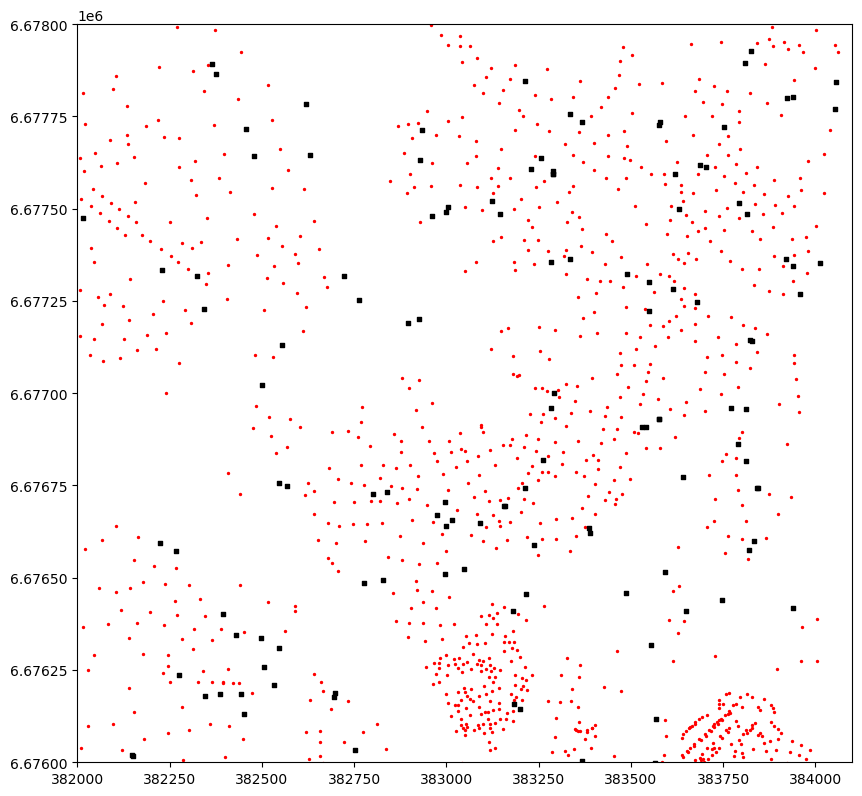

In [41]:
ax = closest.plot(lw=0.5, figsize=(10, 10))
ax = building_points.plot(ax=ax, color="red", markersize=2)
ax = stops.plot(ax=ax, color="black", markersize=8.5, marker="s")
# Zoom to specific area
ax.set_xlim(382000, 384100)
ax.set_ylim(6676000, 6678000);

_**Figure 6.48**. A map showing the buildings (red points), the stops (black rectangles) and the lines between the buildings and the closest stops._

As we can see from the Figure 6.48, the nearest neighbor search have worked well as planned, and each building marked with red color has been correctly connected with a line to the closest stop. The map reveals that there are multiple isolated stops that do not have any buildings connected to them. As a practical example, this information could be used e.g. for transport planning by investigating whether these isolated stops are less used by citizens to get on board of the public transport vehicles. This information could again be used by transport planners to decide whether there is a need to maintain these isolated stops. Thus, with these rather simple computations, one can already provide useful information that has relevance in real life. Finally, because we have calculated the distance between buildings and the stops, it is easy to do some descriptive analysis based on this data providing information about levels of access to public transport in the region: 

In [10]:
closest["distance"].describe()

count    159818.000000
mean        229.029606
std         292.348698
min           0.743490
25%          99.771301
50%         163.805853
75%         260.461391
max        7698.270635
Name: distance, dtype: float64

As we can see, the average distance to public transport in the region is around 230 meters. More than 75 % of the buildings seem to be within within 3.5 minute walking time (~260 meters with walking speed of 4.5 kmph) which indicates very good situation in terms of accessibility levels in the region overall. There seem to be some really remote buildings in the data as well, as the longest distance to closest public transport stop is more than 7 kilometers.

### Nearest neighbors with Polygon and LineString data

In some cases, you might need to find the closest neighbors for a given set of Polygons or LineStrings. Luckily, the `sjoin_nearest()` method works in a similar manner with all geometry types, i.e. you can find the nearest neighbors using Point, LineString, Polygon, MultiPoint, MultiLineString and MultiPoint geometries as input. Also finding nearest neighbors between different geometry types is supported, meaning that you can for example search nearest LineStrings to Polygons, and so on. When using more complex geometries as input (e.g. LineStrings or Polygons), the nearest neighbor search uses spatial index, i.e. it creates bounding boxes around the input geometries and inserts them into an R-Tree which is used to make the search queries more efficient. However, the distance between the nearest neighbours is measured based on the true shapes of the geometric features. In the following, we demonstrate how to conduct nearest neighbor analysis with more complex geometries, such as Polygons and LineStrings.

As a real-life case, we first aim to find the closest urban park to building polygons in a neighborhood called Kamppi, which is located in Helsinki, Finland. Then, we aim to find the closest drivable road (LineString) to each building. Let's start by reading the data and visualize it on a map:

In [43]:
import geopandas as gpd

buildings = gpd.read_file("data/Helsinki/Kamppi_buildings.gpkg")
parks = gpd.read_file("data/Helsinki/Kamppi_parks.gpkg")
roads = gpd.read_file("data/Helsinki/Kamppi_roads.gpkg")
buildings

,osmid,building,name,geometry
0,11711721042,yes,Nice Bike Pyörähuolto,POINT (384966.661 6671503.786)
1,8035238,public,Lasipalatsi,"POLYGON ((385459.65 6672184.469, 385456.356 66..."
2,8042297,yes,Radisson Blu Royal,"POLYGON ((385104.154 6671916.693, 385101.584 6..."
3,14797170,school,None,"POLYGON ((384815.326 6671762.71, 384815.792 66..."
4,14797171,yes,None,"POLYGON ((384797.759 6671853.253, 384798.253 6..."
...,...,...,...,...
450,8092998,yes,None,"POLYGON ((384747.465 6671811.996, 384744.27 66..."
451,8280536,apartments,None,"POLYGON ((384839.007 6671934.815, 384839.485 6..."
452,8525159,civic,None,"POLYGON ((385495.275 6672164.009, 385494.928 6..."
453,8525161,civic,None,"POLYGON ((385486.225 6672173.653, 385486.717 6..."


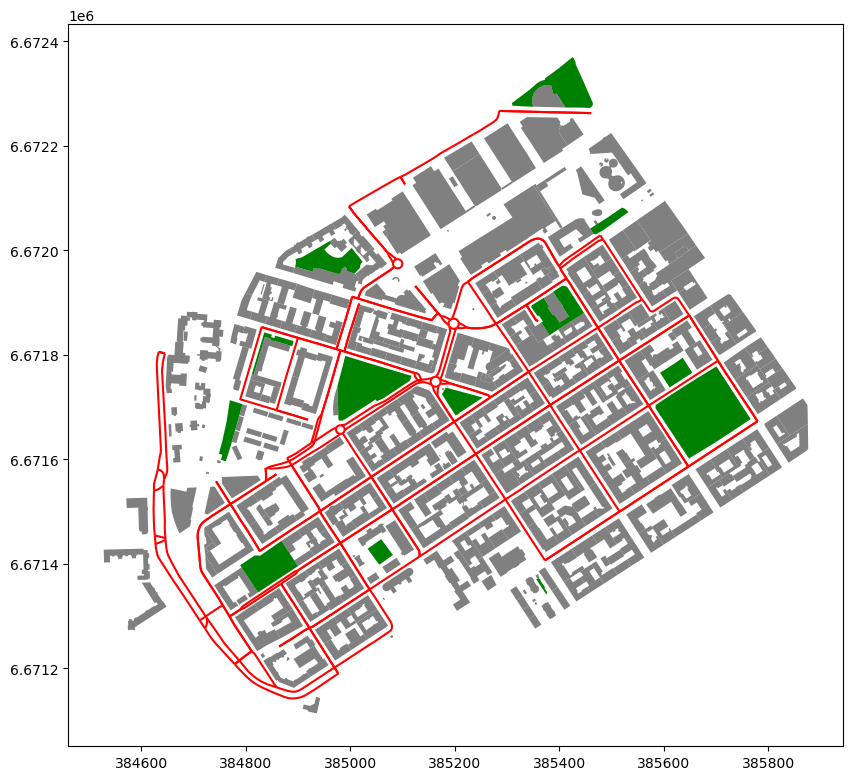

In [44]:
# Plot buildings, parks and roads
ax = buildings.plot(color="gray", figsize=(10, 10))
ax = parks.plot(ax=ax, color="green")
ax = roads.plot(ax=ax, color="red")

_**Figure 6.49**. A map showing the buildings with gray color and the parks (green) in the neighborhood of Kamppi, Helsinki._

Similarly as finding the nearest neighbor using Points as input data, we can use the `.sjoin_nearest()` to find nearest neighbor between two Polygon datasets. Here, we find the nearest park for each building Polygon and store the distance into the column `distance`:

In [45]:
nearest_parks = buildings.sjoin_nearest(parks, distance_col="distance")
nearest_parks

,osmid_left,building,name_left,geometry,index_right,osmid_right,leisure,name_right,distance
0,11711721042,yes,Nice Bike Pyörähuolto,POINT (384966.661 6671503.786),12,1227991181,park,Kaartin lasaretin puisto,100.208527
1,8035238,public,Lasipalatsi,"POLYGON ((385459.65 6672184.469, 385456.356 66...",1,8042613,park,Simonpuistikko,16.284929
2,8042297,yes,Radisson Blu Royal,"POLYGON ((385104.154 6671916.693, 385101.584 6...",8,37390082,park,None,40.039501
3,14797170,school,None,"POLYGON ((384815.326 6671762.71, 384815.792 66...",5,26999855,park,None,0.000000
4,14797171,yes,None,"POLYGON ((384797.759 6671853.253, 384798.253 6...",5,26999855,park,None,14.873403
...,...,...,...,...,...,...,...,...,...
450,8092998,yes,None,"POLYGON ((384747.465 6671811.996, 384744.27 66...",5,26999855,park,None,70.819624
451,8280536,apartments,None,"POLYGON ((384839.007 6671934.815, 384839.485 6...",8,37390082,park,None,38.574646
452,8525159,civic,None,"POLYGON ((385495.275 6672164.009, 385494.928 6...",1,8042613,park,Simonpuistikko,32.792083
453,8525161,civic,None,"POLYGON ((385486.225 6672173.653, 385486.717 6...",1,8042613,park,Simonpuistikko,90.919207


In [46]:
print("Maximum distance:", nearest_parks["distance"].max().round(0))
print("Average distance:", nearest_parks["distance"].mean().round(0))

Maximum distance: 229.0
Average distance: 61.0


Now we have found the nearest park for each building, and as we can see on average the closest park seem to be 61 meters away from the buildings while the longest distance from one of the buildings to the closest park seems to be 229 meters. In a similar manner, we can also find the nearest road from each building as follows:

In [47]:
nearest_roads = buildings.sjoin_nearest(roads, distance_col="distance")
nearest_roads

,osmid_left,building,name_left,geometry,index_right,osmid_right,name_right,highway,distance
0,11711721042,yes,Nice Bike Pyörähuolto,POINT (384966.661 6671503.786),182,"[126894680, 126894676, 126894678, 126894679]",Eerikinkatu,residential,11.181066
0,11711721042,yes,Nice Bike Pyörähuolto,POINT (384966.661 6671503.786),24,"[126894680, 126894676, 126894678, 126894679]",Eerikinkatu,residential,11.181066
1,8035238,public,Lasipalatsi,"POLYGON ((385459.65 6672184.469, 385456.356 66...",15,"[42574048, 42574049, 28920739, 77891210, 26999...",Arkadiankatu,secondary,52.015824
1,8035238,public,Lasipalatsi,"POLYGON ((385459.65 6672184.469, 385456.356 66...",33,"[42574048, 42574049, 28920739, 77891210, 26999...",Arkadiankatu,secondary,52.015824
2,8042297,yes,Radisson Blu Royal,"POLYGON ((385104.154 6671916.693, 385101.584 6...",83,"[37135576, 8035726, 37135575]",Salomonkatu,residential,6.659959
...,...,...,...,...,...,...,...,...,...
452,8525159,civic,None,"POLYGON ((385495.275 6672164.009, 385494.928 6...",107,51707742,Yrjönkatu,residential,88.553223
453,8525161,civic,None,"POLYGON ((385486.225 6672173.653, 385486.717 6...",15,"[42574048, 42574049, 28920739, 77891210, 26999...",Arkadiankatu,secondary,90.569914
453,8525161,civic,None,"POLYGON ((385486.225 6672173.653, 385486.717 6...",33,"[42574048, 42574049, 28920739, 77891210, 26999...",Arkadiankatu,secondary,90.569914
454,8535506,civic,None,"POLYGON ((385481.13 6672167.861, 385482.372 66...",15,"[42574048, 42574049, 28920739, 77891210, 26999...",Arkadiankatu,secondary,96.128437


As a result, we now have found the nearest road for each building. We have now 703 rows of data which means that for some buildings there have been more than one road that are exactly the same distance apart. To better understand how the spatial join between the buildings and roads have been conducted, we can again visualize the nearest neighbors with a straight line. To do this, we first bring the geometries from the `roads` `GeoDataFrame` into the same table with the buildings: 

In [48]:
nearest_roads = nearest_roads.merge(
    roads[["geometry"]], left_on="index_right", right_index=True
)
nearest_roads.head(3)

,osmid_left,building,name_left,geometry_x,index_right,osmid_right,name_right,highway,distance,geometry_y
0,11711721042,yes,Nice Bike Pyörähuolto,POINT (384966.661 6671503.786),182,"[126894680, 126894676, 126894678, 126894679]",Eerikinkatu,residential,11.181066,"LINESTRING (385040.141 6671566.384, 385034.832..."
0,11711721042,yes,Nice Bike Pyörähuolto,POINT (384966.661 6671503.786),24,"[126894680, 126894676, 126894678, 126894679]",Eerikinkatu,residential,11.181066,"LINESTRING (384942.149 6671500.856, 384950.743..."
1,8035238,public,Lasipalatsi,"POLYGON ((385459.65 6672184.469, 385456.356 66...",15,"[42574048, 42574049, 28920739, 77891210, 26999...",Arkadiankatu,secondary,52.015824,"LINESTRING (385285.226 6672266.801, 385296.799..."


Now we have the `geometry_x` column representing the building geometries and the `geometry_y` column representing the road geometries (LineStrings). To visualize the connecting lines between buildings and roads, we first need to create geometries that connect the building and closest road geometry from the locations where the distance is shortest. To do this, we can take advantage of a handy function called `shortest_line()` from the `shapely` library that returns a LineString object between the input geometries showing the shortest distance between them. Based on these, we can create a connecting line between a given building and the closest road. Finally, we create a new `GeoDataFrame` called `connectors` out of these lines and also store the length of the `LineString`s as a separate column:

In [57]:
from shapely import shortest_line


# Generate LineString between nearest points of two geometries
connectors = nearest_roads.apply(
    lambda row: shortest_line(row["geometry_x"], row["geometry_y"]), axis=1
)

# Create a new GeoDataFrame out of these geometries
connectors = gpd.GeoDataFrame({"geometry": connectors}, crs=roads.crs)
connectors["distance"] = connectors.length
connectors.head()

,geometry,distance
0,"LINESTRING (384966.661 6671503.786, 384960.444...",11.181066
0,"LINESTRING (384966.661 6671503.786, 384960.444...",11.181066
1,"LINESTRING (385487.966 6672217.975, 385460.972...",52.015824
1,"LINESTRING (385487.966 6672217.975, 385460.972...",52.015824
2,"LINESTRING (385050.507 6671936.92, 385046.795 ...",6.659959


Great, now we have a new `GeoDataFrame` that represents the connectors between the buildings and the drivable roads. Finally, we can visualize the buildings, roads and these connectors to better understand the exact points where the distance between a given building and the closest road is shortest:

In [58]:
m = buildings.explore(color="gray", tiles="CartoDB Positron")
m = roads.explore(m=m, color="red")
m = connectors.explore(m=m, color="green")
m

_**Figure 6.50**. A map showing the closest road for each building. The LineStrings marked with green color show the exact location where the distance between a given building and the road is shortest._

#### Question 6.11

What is the closest road to each park? Use the `parks` and `roads` `GeoDataFrames` and follow the approaches presented above to find the closest road to each park. What is the highest (maximum) distance between parks and roads present in our datasets?

In [19]:
# You can use this cell to enter your solution.

In [20]:
# Solution

# Find the nearest road
nearest_park_roads = parks.sjoin_nearest(roads, distance_col="distance")

# What is the maximum distance?
max_dist = nearest_park_roads["distance"].max()
print(f"Maximum distance is {max_dist:.2f} meters.")

Maximum distance is 35.14 meters.


## K-Nearest Neighbor search

Thus far, we have only focused on finding the nearest neighbor to a given geometry. However, quite commonly you might want to find not only the closest geometry, but a specific number of closest geometries to a given location (1st closest, 2nd closest, and so on). For example, you might be interested to find 3-5 closest public transport stops from your home, because these stops might provide alternative connections to different parts of the city. Doing these kind of queries is a common procedure and a prerequisite for many data analysis techniques, and the technique is commonly called as *{term}`K-Nearest Neighbors search`* (or KNN search). Next, we will learn how to find *k* number of closest neighbors based on two `GeoDataFrames`. We will first aim to find the three nearest public transport stops for each building in the Helsinki Region, and then we will see how to make a *{term}`radius query`* to find all neighbors within specific distance apart from a given location. K-Nearest Neighbor search techniques are also typically built on top of *{term}`spatial indices <spatial index>`* to make the queries more efficient. Previously, with `sjoin_nearest()`, we used an `R-tree` index structure to efficiently find the nearest neighbor for any kind of geometry. However, because the R-tree implementation in Python only supports finding the closest neighbor (a limitation in the underlying GEOS software), we need to use another tree structure called *{term}`KD-Tree`* (K-dimensional tree) that can provide us information about K-nearest neighbors (i.e. not only the closest). KD-tree is similar to R-tree, but the data is ordered and sorted in a bit different manner (see Appendices for further details). 

In Python, we can conduct KNN search between Point datasets using the `scipy` library. Before we can do the actual query, we need to build the `KD-Tree` spatial index. In scipy, we can use the `KDTree` to build the spatial index which is available from the `scipy.spatial` submodule. The `KDTree` has been implemented in C-language which makes it very fast. In the following, we use the `building_points` and `stops` `GeoDataFrames` that we already used earlier to find three closest public transport stops for each building. Let's start by reading the data and reproject the data into a metric coordinate reference system (EPSG:3067) so that the distances will be presented as meters:

In [21]:
import geopandas as gpd

# Read the files and reproject to EPSG:3067
stops = gpd.read_file("data/Helsinki/pt_stops_helsinki.gpkg").to_crs(epsg=3067)
building_points = gpd.read_file("data/Helsinki/building_points_helsinki.zip").to_crs(
    epsg=3067
)

building_points.head(2)

,name,geometry
0,None,POINT (381166.6 6676424.438)
1,Uimastadion,POINT (385236.565 6674238.472)


In [22]:
stops.head(2)

,stop_name,stop_lat,stop_lon,stop_id,geometry
0,Ritarihuone,60.16946,24.95667,1010102,POINT (386623.301 6672037.884)
1,Kirkkokatu,60.17127,24.95657,1010103,POINT (386623.991 6672239.572)


In [23]:
stops.shape

(8377, 5)

As we see, both datasets include Point geometries representing specific buildings and public transport stops (n=8377). 

As a first step, we need to build a `KDTRee` index structure based on the Point coordinates. The `KDTree` class expects the Point coordinates to be in `array` format, i.e. not as shapely `Point` objects which we have stored in the `geometry` column. Luckily, it is very easy to convert the shapely geometries into `numpy.array` format by chaining a method `.get_coordinates()` with the `.to_numpy()` method as follows: 

In [24]:
building_coords = building_points.get_coordinates().to_numpy()
stop_coords = stops.geometry.get_coordinates().to_numpy()

stop_coords

array([[ 386623.30055697, 6672037.88387716],
       [ 386623.99053928, 6672239.57164472],
       [ 386629.00011373, 6672130.5382358 ],
       ...,
       [ 393706.51571504, 6707260.21305267],
       [ 391372.74617002, 6697807.78260742],
       [ 388733.41604041, 6714694.15542812]])

By running these commands, the `.get_coordinates()` method first returns a DataFrame with `x` and `y` coordinates as columns, and the `.to_numpy()` method then converts this data into a numpy `array` as we see above. The `stop_coords` variable now contains an array of coordinate tuples (x and y coordinates) which we can pass to the `KDTree` class and create a KD-Tree index structure as follows: 

In [25]:
from scipy.spatial import KDTree

stop_kdt = KDTree(stop_coords)
stop_kdt

Now we have initialized a `KDTree` index structure by populating it with stop coordinates. By doing this, we can make very efficient queries to find out which of the ~8000 stops is closest to specific buildings. To do this, we can use the `.query()` method which goes through all the input coordinates (i.e. buildings) and very quickly calculates which of them is the closest, 2nd closest etc. The method returns the distances to the K-number of nearest neighbors as well as the index of the closest `stop` to the given building. By passing an argument `k=3`, we can specify that we want to find three closest neighbors for each building: 

In [26]:
# Find the three nearest neighbors from stop KD-Tree for each building
k_nearest_dist, k_nearest_ix = stop_kdt.query(building_coords, k=3)

len(k_nearest_dist)

158731

The `stop_kdt.query()` call returns us two objects. The first one which we store to variable `k_nearest_dist` represents an array/list of distances from each building (n=158 731) to the three of the closest public transport stops in the data. The second variable `k_nearest_ix` represents the index values of the three nearest stops for each building: 

In [27]:
# Distances to 3 nearest stops
k_nearest_dist

array([[ 92.67989301, 461.43820422, 466.16915044],
       [400.24336963, 409.49707253, 410.06137016],
       [109.81963349, 130.59749777, 133.6424814 ],
       ...,
       [135.34174505, 136.28586705, 274.93549394],
       [ 99.40810774, 118.1492825 , 209.42172325],
       [ 67.79042163,  71.91370036, 103.08138812]])

In [28]:
# Index values of the 3 nearest stops
k_nearest_ix

array([[1131, 1135, 1125],
       [ 467,  465,  475],
       [  61,   64,   13],
       ...,
       [4655, 4678, 4614],
       [4624, 4625, 4680],
       [4665, 4617, 4619]])

Based on these arrays, we can see that the closest stop to the first building in our data is 92.7 meters away from the building, while the second and third closest stops are approximately 460 meters away from the given building. By looking at the index values in the `k_nearest_ix` variable, we can see that the stops with indices 1131, 1135 and 1125 seem to be the three closest public transport stops to the first building in our data. 

Now we have successfully computed the K-nearest neighbors between the buildings and the stops. Next, we will attach this information back to our `GeoDataFrame` so that it is easier to do further analyses with the data and create some nice maps out of the data. The data which is returned by the `stop_kdt.query()` command comes out as an array of lists, where each item (list) contains three values that show the distances between three nearest stops and the given building. To be able to easily merge this data with the original `GeoDataFrame` containing the building data, we need to transpose our arrays. After the transpose, the data will be restructured in a way that there will be three arrays and each of these arrays contains the distances/stop-ids for all the buildings in a single list. To transpose a numpy array, we can use the method `.T` which does the trick:

In [29]:
k_nearest_ix.T

array([[1131,  467,   61, ..., 4655, 4624, 4665],
       [1135,  465,   64, ..., 4678, 4625, 4617],
       [1125,  475,   13, ..., 4614, 4680, 4619]])

By following this approach, we can store the index and distance information as columns into our `GeoDataFrame` containing values for the 1-3 nearest stops. In the following, we first create a clean copy of the `building_points` `GeoDataFrame` into variable `k_nearest`, which we will then populate with three new columns for the stop indices, and three columns for the distances to the 1-3 closest stops. To access the information for the closest stop, we can call `.T[0]`, while the `.T[1]` and `.T[2]` returns the information for the second and third closest stops accordingly:

In [30]:
# Make a copy
k_nearest = building_points.copy()

# Add indices of nearest stops
k_nearest["1st_nearest_idx"] = k_nearest_ix.T[0]
k_nearest["2nd_nearest_idx"] = k_nearest_ix.T[1]
k_nearest["3rd_nearest_idx"] = k_nearest_ix.T[2]

# Add distances
k_nearest["1st_nearest_dist"] = k_nearest_dist.T[0]
k_nearest["2nd_nearest_dist"] = k_nearest_dist.T[1]
k_nearest["3rd_nearest_dist"] = k_nearest_dist.T[2]

In [31]:
k_nearest.head()

,name,geometry,1st_nearest_idx,2nd_nearest_idx,3rd_nearest_idx,1st_nearest_dist,2nd_nearest_dist,3rd_nearest_dist
0,None,POINT (381166.6 6676424.438),1131,1135,1125,92.679893,461.438204,466.169150
1,Uimastadion,POINT (385236.565 6674238.472),467,465,475,400.243370,409.497073,410.061370
2,None,POINT (386317.478 6672100.648),61,64,13,109.819633,130.597498,133.642481
3,Hartwall Arena,POINT (385225.109 6676120.56),532,533,506,104.632434,137.706391,377.331985
4,Talli,POINT (385079.733 6676989.745),496,497,498,472.248282,519.685534,551.358778


Perfect! Now we have stored the information for each building about the indices and distances to the three of the closest stops around given buildings. To make this information easier to understand, we can make a nice map that shows the closest three stops for each building. To do this, we can follow a similar approach as we used earlier when visualizing the results from the `sjoin_nearest()` function. Namely, we bring the geometry from the k-nearest stops and connect the building Points with the given stop Points with a LineString. Then it is easy to visualize the closest stops for each building. In the following, we create three separate `GeoDataFrames` that correspond to the nearest, second nearest and third nearest stops from the buildings. We start by storing the `stop_index` as a column which allows us to easily merge the data between `stops` and `k_nearest` (buildings) GeoDataFrames. For making the table join, we can use the pandas `.merge()` function in which we use the `1st_nearest_idx`,  `2nd_nearest_idx` and `3rd_nearest_idx` as the key on the left `GeoDataFrame`, while the `stop_index` is the key on the right `GeoDataFrame`. We also pass the `suffixes=('', '_knearest)` argument to the `.merge()` method to specify that the column names on the left-side `GeoDataFrame` should stay as they are, while the column names on the right-side will get a suffix `_knearest` in case there are identical column names present in both `GeoDataFrames` (which we have as both frames contain the `geometry` column. Let's see how we can create these three `GeoDataFrames` and store them into `k_nearest_1`, `k_nearest_2` and `k_nearest_3` variables:

In [32]:
# Store the stop index for making the table join
stops["stop_index"] = stops.index

In [33]:
# Merge the geometries of the nearest stops to the GeoDataFrame
k_nearest_1 = k_nearest.merge(
    stops[["stop_index", "geometry"]],
    left_on="1st_nearest_idx",
    right_on="stop_index",
    suffixes=("", "_knearest"),
)
k_nearest_1.head(2)

,name,geometry,1st_nearest_idx,2nd_nearest_idx,3rd_nearest_idx,1st_nearest_dist,2nd_nearest_dist,3rd_nearest_dist,stop_index,geometry_knearest
0,None,POINT (381166.6 6676424.438),1131,1135,1125,92.679893,461.438204,466.16915,1131,POINT (381256.66 6676446.317)
1,Uimastadion,POINT (385236.565 6674238.472),467,465,475,400.243370,409.497073,410.06137,467,POINT (384973.331 6674539.973)


In [34]:
# Merge the geometries of the 2nd nearest stops to the GeoDataFrame
k_nearest_2 = k_nearest.merge(
    stops[["stop_index", "geometry"]],
    left_on="2nd_nearest_idx",
    right_on="stop_index",
    suffixes=("", "_knearest"),
)
k_nearest_2.head(2)

,name,geometry,1st_nearest_idx,2nd_nearest_idx,3rd_nearest_idx,1st_nearest_dist,2nd_nearest_dist,3rd_nearest_dist,stop_index,geometry_knearest
0,None,POINT (381166.6 6676424.438),1131,1135,1125,92.679893,461.438204,466.16915,1135,POINT (381625.316 6676474.488)
1,Uimastadion,POINT (385236.565 6674238.472),467,465,475,400.243370,409.497073,410.06137,465,POINT (385270.775 6674646.538)


In [35]:
# Merge the geometries of the 3rd nearest stops to the GeoDataFrame
k_nearest_3 = k_nearest.merge(
    stops[["stop_index", "geometry"]],
    left_on="3rd_nearest_idx",
    right_on="stop_index",
    suffixes=("", "_knearest"),
)
k_nearest_3.head(2)

,name,geometry,1st_nearest_idx,2nd_nearest_idx,3rd_nearest_idx,1st_nearest_dist,2nd_nearest_dist,3rd_nearest_dist,stop_index,geometry_knearest
0,None,POINT (381166.6 6676424.438),1131,1135,1125,92.679893,461.438204,466.16915,1125,POINT (381632.74 6676429.668)
1,Uimastadion,POINT (385236.565 6674238.472),467,465,475,400.243370,409.497073,410.06137,475,POINT (385122.17 6674632.254)


Excellent, now we have merged the stop geometries into the `geometry_knearest` columns. By comparing the values in the `stop_index` column of the `GeoDataFrames` `k_nearest_1`, `k_nearethe st_2` and `k_nearest_3`, we can see that the values change correctly following the values in `1st_`, `2nd_` and `3rd_nearest_index` column accordingly. The geometries stored in the `geometry_knearest` also have different values in all of the `GeoDataFrames` which is as expected. Now we can create `LineString` geometries connecting these `Point` objects to each other which allows us to create a nice map out of our nearest neighbors and thus better understand the data:

In [36]:
from shapely import LineString

# Generate LineStrings connecting the building point and K-nearest neighbor
k_nearest_1["geometry"] = k_nearest_1.apply(
    lambda row: LineString([row["geometry"], row["geometry_knearest"]]), axis=1
)
k_nearest_2["geometry"] = k_nearest_2.apply(
    lambda row: LineString([row["geometry"], row["geometry_knearest"]]), axis=1
)
k_nearest_3["geometry"] = k_nearest_3.apply(
    lambda row: LineString([row["geometry"], row["geometry_knearest"]]), axis=1
)

k_nearest_1.head(2)

,name,geometry,1st_nearest_idx,2nd_nearest_idx,3rd_nearest_idx,1st_nearest_dist,2nd_nearest_dist,3rd_nearest_dist,stop_index,geometry_knearest
0,None,"LINESTRING (381166.6 6676424.438, 381256.66 66...",1131,1135,1125,92.679893,461.438204,466.16915,1131,POINT (381256.66 6676446.317)
1,Uimastadion,"LINESTRING (385236.565 6674238.472, 384973.331...",467,465,475,400.243370,409.497073,410.06137,467,POINT (384973.331 6674539.973)


Now we have updated the `geometry` column of our datasets with `LineString` geometries connecting the building Point with the nearest stop geometries. Next, it is easy to visualize the closest three stops for each building. Because there are thousands of connections in our data, in the following, we select a specific building and the closest stops from that building. The `name` column contains information about the names of the buildings which we can use to choose a building of our interest for visualization:

In [37]:
# Find unique building names
k_nearest.name.unique()

array([None, 'Uimastadion', 'Hartwall Arena', ..., 'Peltolan koulu',
       'Hilton Helsinki Airport', 'Posti Oy Logistiikkakeskus'],
      dtype=object)

As we can see, one of the buildings is called `Hartwall Arena` which is an interesting example because it is a large sports arena that is reached by thousands of people via public transport whenever there is some event happening. Thus, let's filter the data for that building and create an interactive map out of the results, showing the three closest stops indicated with different colors:

In [48]:
# Visualize 3 nearest stops to
selected_name = "Hartwall Arena"

m = k_nearest_1.loc[k_nearest_1["name"] == selected_name].explore(
    color="red", tiles="CartoDB Positron", max_zoom=16
)
m = k_nearest_2.loc[k_nearest_2["name"] == selected_name].explore(m=m, color="orange")
m = k_nearest_3.loc[k_nearest_3["name"] == selected_name].explore(m=m, color="blue")
m = stops.explore(m=m, color="green")
m

_**Figure 6.51**. A map showing the three closest public transport stops to the selected building (Hartwall Arena). The LineString marked with red color show the closest stop, while the line indicated with blue color shows the 3rd closest stop._

From the map, we can see that the closest stops to the arena seem to be located close to a large road 100-130 meters away from the arena, while the third closest stop is closer to the rail roads 377 meters away (Euclidean distance) from the building. 

### Nearest neighbors within radius

As a last example related to nearest neighbors we show how to find all neighbors of a given Point geometry within a specific distance threshold. As a practical example, we aim to find and calculate the number of buildings that are within 200 meters from a given public transport stop. Doing this kind of nearest neighbor query is similar to the one that we did with `.sjoin_nearest()` using the `max_distance` parameter, but here we aim to efficiently retrieve all neighbors within the given search radius, not only the closest one which is how `sjoin_nearest()` operates. Finding all neighbors within a specific search radius can also be done using the KD-Tree spatial index. However, in this case we actually build the `KDTree` index for both datasets (buildings and stops) and then use a `.query_ball_tree()` method to find all neighbors within the radius `r`: 

In [39]:
from scipy.spatial import KDTree

# Build KDTree indices
stop_kdt = KDTree(stop_coords)
building_kdt = KDTree(building_coords)

# Find the three nearest neighbors from stop KD-Tree for each building
k_nearest_ix = stop_kdt.query_ball_tree(building_kdt, r=200)

In [40]:
len(k_nearest_ix)

8377

Now we have found all the building points within 200 meters from the stops (n=8377). As a result, we get a list of building index values for each stop. The following shows all the indices for the first stop at index 0:

```python
k_nearest_ix[0]
```

```
[1129,
 1130,
 1155,
 2054,
 2055,
 2056,
... (output truncated)
```

Now we can easily store the building indices as a new column to the `stops` `GeoDataFrame`:

In [41]:
stops["building_ids_within_range"] = k_nearest_ix
stops.head()

,stop_name,stop_lat,stop_lon,stop_id,geometry,stop_index,building_ids_within_range
0,Ritarihuone,60.169460,24.956670,1010102,POINT (386623.301 6672037.884),0,"[1129, 1130, 1155, 2054, 2055, 2056, 2057, 205..."
1,Kirkkokatu,60.171270,24.956570,1010103,POINT (386623.991 6672239.572),1,"[1130, 2054, 2055, 2057, 2058, 2059, 2066, 206..."
2,Kirkkokatu,60.170293,24.956721,1010104,POINT (386629 6672130.538),2,"[1129, 1130, 2054, 2055, 2056, 2057, 2058, 205..."
3,Vironkatu,60.172580,24.956554,1010105,POINT (386627.617 6672385.448),3,"[2060, 2062, 2063, 2064, 2065, 2066, 2067, 206..."
4,Vironkatu,60.172990,24.956380,1010106,POINT (386619.379 6672431.394),4,"[1136, 2060, 2061, 2062, 2063, 2064, 2065, 206..."


With this information, we can for example calculate the number of buildings within 200 meters from each stop. To do this, we can create a simple `lambda` function that checks the length of the id-list and store the result into column `building_cnt`:

In [42]:
stops["building_cnt"] = stops["building_ids_within_range"].apply(
    lambda id_list: len(id_list)
)
stops.head()

,stop_name,stop_lat,stop_lon,stop_id,geometry,stop_index,building_ids_within_range,building_cnt
0,Ritarihuone,60.169460,24.956670,1010102,POINT (386623.301 6672037.884),0,"[1129, 1130, 1155, 2054, 2055, 2056, 2057, 205...",50
1,Kirkkokatu,60.171270,24.956570,1010103,POINT (386623.991 6672239.572),1,"[1130, 2054, 2055, 2057, 2058, 2059, 2066, 206...",69
2,Kirkkokatu,60.170293,24.956721,1010104,POINT (386629 6672130.538),2,"[1129, 1130, 2054, 2055, 2056, 2057, 2058, 205...",56
3,Vironkatu,60.172580,24.956554,1010105,POINT (386627.617 6672385.448),3,"[2060, 2062, 2063, 2064, 2065, 2066, 2067, 206...",74
4,Vironkatu,60.172990,24.956380,1010106,POINT (386619.379 6672431.394),4,"[1136, 2060, 2061, 2062, 2063, 2064, 2065, 206...",78


In [43]:
print("Max number of buildings:", stops["building_cnt"].max())
print("Average number of buildings:", stops["building_cnt"].mean().round(1))

Max number of buildings: 181
Average number of buildings: 32.2


By calculating simple statistics from the `building_cnt` column, we can see that on average there are 32.2 buildings within 200 meters from the public transport stops and the maximum number of buildings within this distance is whopping 181 buildings. This indicates very dense neighborhood having numerous buildings in a small area. To better understand, where this kind of neighborhood is located and what does it look like, we can make a map by selecting the rows with highest number of buildings and then plotting the stop and building points within radius:

In [47]:
filtered = stops["building_cnt"] == stops["building_cnt"].max()
building_ids = stops.loc[filtered].building_ids_within_range.values[0]

m = stops.loc[filtered].explore(
    tiles="CartoDB Positron", color="red", marker_kwds={"radius": 5}, max_zoom=16
)
building_points.loc[building_ids].explore(m=m)

_**Figure 6.52**. A map showing the public transport stop with highest number of buildings surrounding it within 200 meter radius._

The map reveals that this stop is indeed located in a densely built neighborhood called Laurinlahti with lots of detached houses. By using a similar approach, it is possible to investigate the urban design and morphology across the city regions which can reveal some interesting patterns and developments relevant to urban planning. 

There is also an alternative approach for making a radius query by calculating a buffer around the stop points and then making a spatial join between these Polygon geometries and the buildings. This approach also allows to make queries between other type of geometries than Points.

#### Question 6.12

Test and try to find all buildings within 200 meters from the transit stops by creating a 200 meter buffer around the stops and then making a spatial join between the buffers and building points. Calculate the number of buildings per stop_id. Did it take longer to find the nearest buildings using this approach?

In [45]:
# You can use this cell to enter your solution.

In [46]:
# Solution

# Create a 200 meter buffer
stop_buffer = stops.copy()
stop_buffer["geometry"] = stops.buffer(200)

# Find all the building points intersecting with the buffer
buffer_buildings = stop_buffer.sjoin(building_points, predicate="intersects")

# Calculate the number of buildings per stop by grouping
building_count = (
    buffer_buildings.groupby("stop_id").stop_name.count().to_frame().reset_index()
)

# Now the "stop_name" column contains information about building count, rename
building_count = building_count.rename(columns={"stop_name": "building_cnt_buffer"})

# Join the information into the stops
stop_buffer = stop_buffer.merge(building_count, on="stop_id")

# As a result, we should have identical number of buildings identified per stop (see the last two columns)
stop_buffer.head()

,stop_name,stop_lat,stop_lon,stop_id,geometry,stop_index,building_ids_within_range,building_cnt,building_cnt_buffer
0,Ritarihuone,60.169460,24.956670,1010102,"POLYGON ((386823.301 6672037.884, 386822.338 6...",0,"[1129, 1130, 1155, 2054, 2055, 2056, 2057, 205...",50,50
1,Kirkkokatu,60.171270,24.956570,1010103,"POLYGON ((386823.991 6672239.572, 386823.027 6...",1,"[1130, 2054, 2055, 2057, 2058, 2059, 2066, 206...",69,69
2,Kirkkokatu,60.170293,24.956721,1010104,"POLYGON ((386829 6672130.538, 386828.037 66721...",2,"[1129, 1130, 2054, 2055, 2056, 2057, 2058, 205...",56,56
3,Vironkatu,60.172580,24.956554,1010105,"POLYGON ((386827.617 6672385.448, 386826.654 6...",3,"[2060, 2062, 2063, 2064, 2065, 2066, 2067, 206...",74,74
4,Vironkatu,60.172990,24.956380,1010106,"POLYGON ((386819.379 6672431.394, 386818.416 6...",4,"[1136, 2060, 2061, 2062, 2063, 2064, 2065, 206...",78,78
